# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





In [5]:
import numpy as np

import matplotlib.pyplot as plt

with open("africa_dataset_v.csv", "r") as f:
    lines = [line.strip().split(",") for line in f if line.strip() != ""]

header = lines[0]
raw_rows = lines[1:]

country_names = np.array([row[0] for row in raw_rows])
region_raw = np.array([row[1] for row in raw_rows])
income_raw = np.array([row[2] for row in raw_rows])   # "" for Ethiopia = real missing value
numeric_raw = [row[3:] for row in raw_rows]
numeric_cols = header[3:]

data = np.array([[np.nan if v == "" else float(v) for v in row] for row in numeric_raw])
print("Numeric data shape:", data.shape)
print("Missing values per numeric column:", np.isnan(data).sum(axis=0))

unique_regions = np.unique(region_raw)
region_map = {r: i for i, r in enumerate(unique_regions)}
region_encoded = np.array([region_map[r] for r in region_raw], dtype=float).reshape(-1, 1)

unique_income = np.unique(income_raw)   # "" is its own valid category (unclassified)
income_map = {v: i for i, v in enumerate(unique_income)}
income_encoded = np.array([income_map[v] for v in income_raw], dtype=float).reshape(-1, 1)

full_data = np.hstack([region_encoded, income_encoded, data])
all_col_names = ["region_encoded", "income_group_encoded"] + numeric_cols

col_means = np.nanmean(full_data, axis=0)
nan_mask = np.isnan(full_data)
full_data[nan_mask] = np.take(col_means, np.where(nan_mask)[1])
assert not np.isnan(full_data).any()

Numeric data shape: (25, 4)
Missing values per numeric column: [1 3 1 1]


### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

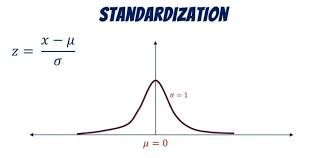


In [6]:
means = full_data.mean(axis=0)
stds = full_data.std(axis=0)
standardized_data = (full_data - means) / stds
standardized_data[:5]

array([[ 1.14263108,  0.47304992,  3.77943848, -0.84289246, -2.20953294,
        -0.48615426],
       [-1.11256184, -2.48351206,  1.30406638, -0.68980054,  0.33075668,
        -1.11717527],
       [-0.36083087,  0.47304992,  1.23697236,  1.05724844,  1.15532254,
         0.08300195],
       [-1.86429282, -1.00523107,  1.40999625, -0.96296455, -0.75234291,
         0.44181781],
       [ 0.39090011,  1.95133091,  0.24170014,  3.24406146,  0.07809873,
         1.5553843 ]])

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [7]:
n_samples = standardized_data.shape[0]
cov_matrix = (standardized_data.T @ standardized_data) / (n_samples - 1)
cov_matrix

array([[ 1.04166667e+00,  1.77803137e-01, -1.41373850e-01,
         7.05406248e-02, -3.85712599e-01, -3.53217175e-01],
       [ 1.77803137e-01,  1.04166667e+00, -4.48826042e-02,
         6.68012946e-01,  2.72403664e-01,  6.61768158e-01],
       [-1.41373850e-01, -4.48826042e-02,  1.04166667e+00,
        -1.28236376e-01, -3.24292329e-01, -2.84807641e-04],
       [ 7.05406248e-02,  6.68012946e-01, -1.28236376e-01,
         1.04166667e+00,  4.92018927e-01,  5.58238871e-01],
       [-3.85712599e-01,  2.72403664e-01, -3.24292329e-01,
         4.92018927e-01,  1.04166667e+00,  3.24797397e-01],
       [-3.53217175e-01,  6.61768158e-01, -2.84807641e-04,
         5.58238871e-01,  3.24797397e-01,  1.04166667e+00]])

We compute the covariance matrix because it tells us how each standardized feature moves together with every other — near zero means unrelated, large positive or negative means overlapping information. PCA needs this because the eigenvectors of the covariance matrix point along the directions where the data varies most, which is exactly what principal components are. It also surfaces redundancy: here, GDP per capita, life expectancy, and literacy tend to rise together, and PCA's job is to compress that shared signal into fewer dimensions.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [8]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
eigenvalues, eigenvectors

(array([2.61610023, 1.37609362, 1.20819258, 0.57798201, 0.16354949,
        0.30808208]),
 array([[-0.12452757, -0.82400742, -0.06779332, -0.16070984, -0.51598951,
         -0.0939995 ],
        [ 0.50157698, -0.34877708,  0.23680721,  0.12855472,  0.46995154,
         -0.57733583],
        [-0.13194104,  0.15898417,  0.81732458, -0.50367042, -0.15224453,
         -0.11150708],
        [ 0.52949082, -0.21610017,  0.01439854, -0.39989762,  0.21556944,
          0.68289427],
        [ 0.41561076,  0.32887283, -0.428874  , -0.51023171, -0.33708504,
         -0.40151554],
        [ 0.5122618 ,  0.13868575,  0.29524009,  0.53264212, -0.57413019,
          0.13361996]]))

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [9]:
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]
sorted_eigenvectors

array([[-0.12452757, -0.82400742, -0.06779332, -0.16070984, -0.0939995 ,
        -0.51598951],
       [ 0.50157698, -0.34877708,  0.23680721,  0.12855472, -0.57733583,
         0.46995154],
       [-0.13194104,  0.15898417,  0.81732458, -0.50367042, -0.11150708,
        -0.15224453],
       [ 0.52949082, -0.21610017,  0.01439854, -0.39989762,  0.68289427,
         0.21556944],
       [ 0.41561076,  0.32887283, -0.428874  , -0.51023171, -0.40151554,
        -0.33708504],
       [ 0.5122618 ,  0.13868575,  0.29524009,  0.53264212,  0.13361996,
        -0.57413019]])

In [10]:
print("Sorted eigenvalues:")
print(sorted_eigenvalues)

Sorted eigenvalues:
[2.61610023 1.37609362 1.20819258 0.57798201 0.30808208 0.16354949]


In [11]:
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)

print("Explained variance ratio:")
print(explained_variance_ratio)

Explained variance ratio:
[0.41857604 0.22017498 0.19331081 0.09247712 0.04929313 0.02616792]


In [12]:
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

print("Cumulative explained variance:")
print(cumulative_explained_variance)

Cumulative explained variance:
[0.41857604 0.63875102 0.83206183 0.92453895 0.97383208 1.        ]


In [13]:
variance_threshold = 0.90

num_components = np.argmax(
    cumulative_explained_variance >= variance_threshold
) + 1

print("Variance threshold:", variance_threshold)
print("Number of components selected:", num_components)
print("Variance retained:", cumulative_explained_variance[num_components - 1])

Variance threshold: 0.9
Number of components selected: 4
Variance retained: 0.9245389493403429


### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [14]:
projection_matrix = sorted_eigenvectors[:, :num_components]

reduced_data = standardized_data @ projection_matrix

print("Number of components used:", num_components)

reduced_data[:5]

Number of components used: 4


array([[-2.0173289 , -1.1175834 ,  3.91552943, -0.8209124 ],
       [-2.07925096,  2.09318381,  0.07153622, -1.28525479],
       [ 1.20148347,  0.49199119,  0.69173202, -1.47228752],
       [-1.05431758,  2.13290524,  1.48000258,  0.46449681],
       [ 3.44509803, -1.42390562,  1.10556334, -0.44238361]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [15]:
print(f'Reduced Data Shape: {reduced_data.shape}')
reduced_data[:5]

Reduced Data Shape: (25, 4)


array([[-2.0173289 , -1.1175834 ,  3.91552943, -0.8209124 ],
       [-2.07925096,  2.09318381,  0.07153622, -1.28525479],
       [ 1.20148347,  0.49199119,  0.69173202, -1.47228752],
       [-1.05431758,  2.13290524,  1.48000258,  0.46449681],
       [ 3.44509803, -1.42390562,  1.10556334, -0.44238361]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

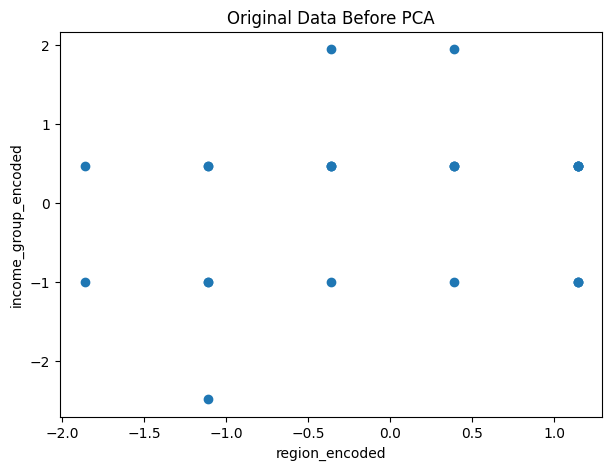

In [17]:
plt.figure(figsize=(7, 5))

plt.scatter(standardized_data[:, 0], standardized_data[:, 1])

plt.xlabel(all_col_names[0])
plt.ylabel(all_col_names[1])
plt.title("Original Data Before PCA")

plt.show()

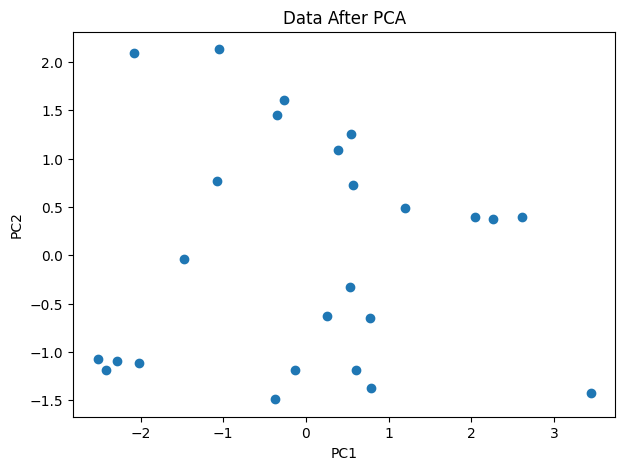

In [18]:
plt.figure(figsize=(7, 5))

plt.scatter(reduced_data[:, 0], reduced_data[:, 1])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Data After PCA")

plt.show()

**Interpretation of the Visual**

Before PCA, the observations appeared more aligned and spread out across the original feature axes. After PCA, the observations appeared more scattered and closer together when viewed using PC1 and PC2. This change occurs because PCA transforms the original features into new principal component axes. The same observations are still represented, but their positions are expressed in a different coordinate system.

Explanation As to Why the Number of Principal Components Was Selected

We selected 4 principal components because they retain approximately 92.45% of the total variance in the dataset. Three components retained only about 83.21%, which was below our 90% threshold. Using 4 components keeps most of the information while reducing the data from 6 dimensions to 4. The tradeoff is that some information is still lost in exchange for a lower-dimensional representation.

What Information Was Lost When Reducing Dimensions?

Reducing the dataset from 6 dimensions to 4 means some variation from the original features is lost. In this dataset, some specific information about population, GDP per capita, life expectancy, literacy rate, and the encoded groups may not be represented as fully. This means small differences in economic activity or population pressure may be less visible after dimensionality reduction. However, about 92.45% of the total variance is retained.

## Task 3: Performance Optimization

The PCA implementation uses NumPy vectorized operations for matrix calculations instead of manually looping through individual values. Vectorization allows calculations such as covariance and projection to be performed efficiently using matrix multiplication. This approach is more suitable for larger datasets because it reduces the need for repeated Python-level loops.


In [ ]:
%timeit standardized_data @ projection_matrix

2.29 µs ± 61.2 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


The projection uses NumPy matrix multiplication, which is a vectorized operation and avoids unnecessary loops. This improves computational efficiency and makes the implementation more suitable for larger datasets. The benchmark measures the time required to project the standardized dataset onto the selected principal components.


Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?
